In [2]:
import numpy as np
import glob
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from oaatutils import *

In [4]:
f='../postp/oaat_postp.nc'
ds=xr.open_dataset(f)

In [5]:
df=pd.read_csv('cats.csv')
cats=np.unique(df.cat.values)

In [6]:
la=xr.open_dataset('sparsegrid_landarea.nc').landarea
cf=24*60*60*365*la.sum()*1e-9

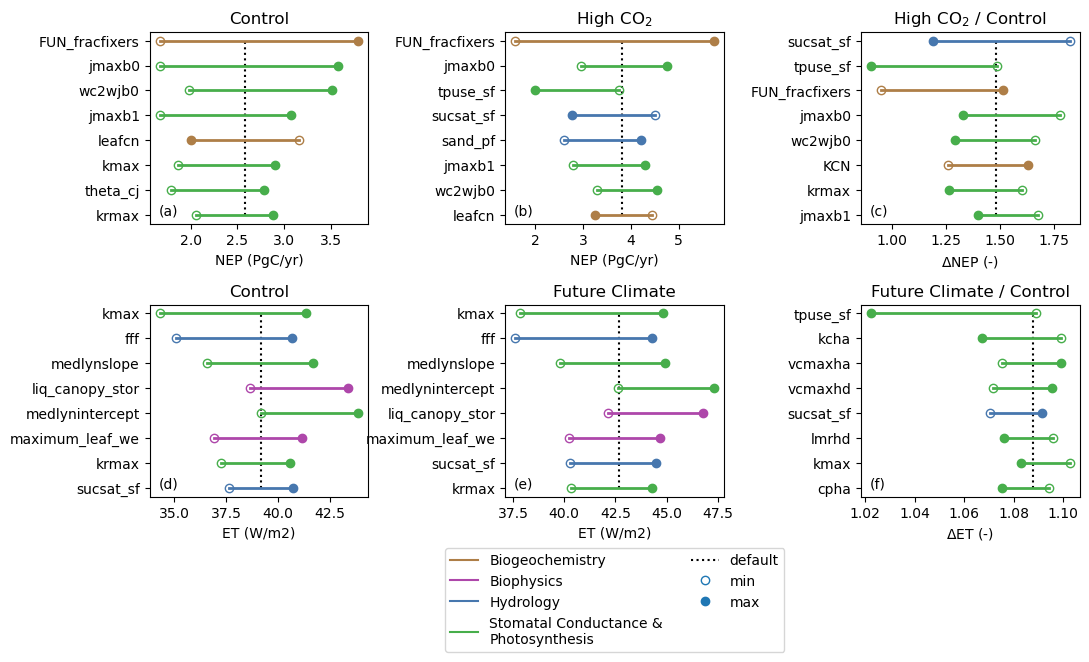

In [42]:

fig,axs=plt.subplot_mosaic('AXBYC;ZZZZZ;DUETF;SSSSS;VGGGW',
                           figsize=[12,8],
                           gridspec_kw={'width_ratios': [3,1,3,1,3],'height_ratios': [3,0.6,3, 0.2,1.5]})

for a in 'GSTUVWXYZ':
    axs[a].axis('off')

x=cf*ds.NEP_global_mean
exp='C867'
nx=8
rank_plot(x.sel(exp='CTL2010'),nx,ax=axs['A'])
rank_plot(x.sel(exp=exp),nx,ax=axs['B'])
rank_plot(x.sel(exp=exp)/x.sel(exp='CTL2010'),nx,ax=axs['C'])

ts=['Control','High CO$_2$','High CO$_2$ / Control']
xlabs=['NEP (PgC/yr)','NEP (PgC/yr)','$\Delta$NEP (-)']
for a,t,xlab in zip('ABC',ts,xlabs):
    axs[a].set_title(t)
    axs[a].set_xlabel(xlab)
    x0,x1=axs[a].get_xlim()
    dx=x1-x0
    axs[a].text(x0+0.04*dx,0,'('+a.lower()+')')

x=ds.EFLX_LH_TOT_global_mean
exp='AF2095'
nx=8
rank_plot(x.sel(exp='CTL2010'),nx,ax=axs['D'])
rank_plot(x.sel(exp=exp),nx,ax=axs['E'])
rank_plot(x.sel(exp=exp)/x.sel(exp='CTL2010'),nx,ax=axs['F'])

ts=['Control','Future Climate','Future Climate / Control']
xlabs=['ET (W/m2)','ET (W/m2)','$\Delta$ET (-)']
for a,t,xlab in zip('DEF',ts,xlabs):
    axs[a].set_title(t)
    axs[a].set_xlabel(xlab)
    x0,x1=axs[a].get_xlim()
    dx=x1-x0
    axs[a].text(x0+0.04*dx,0,'('+a.lower()+')')

#legend
ax=axs['G']
for cat in cats[[0,1,3,4]]:
    ax.plot([1,1],[1,1],color=df.color[df.cat==cat].values[0],label=cat)
ax.set_xlim([-99,-98])
ax.plot([1,1],[1,1],'k:',label='default')
ax.plot(1,2,'C0o',fillstyle='none',label='min')
ax.plot(1,2,'C0o',label='max')
ax.legend(loc=10,ncol=2)
plt.savefig('../figs/main/deltas.png',dpi=300,bbox_inches='tight')

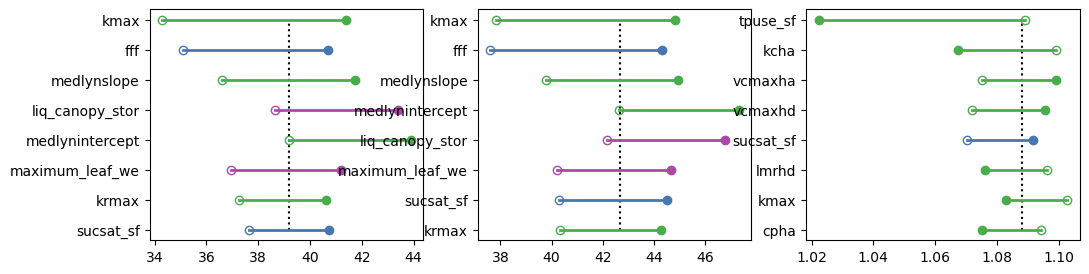

In [24]:
x=ds.EFLX_LH_TOT_global_mean
x[x.param=='csol_sand',:,:]=1
exp='AF2095'

fig,axs=plt.subplots(1,3,figsize=[12,3])

rank_plot(x.sel(exp='CTL2010'),nx,ax=axs[0])
rank_plot(x.sel(exp=exp),nx,ax=axs[1])
rank_plot(x.sel(exp=exp)/x.sel(exp='CTL2010'),nx,ax=axs[2])